# Oligohydramnion - 2 Clusters

Notebook gabungan untuk alur processing/preprocessing, training, testing, dan evaluasi klasterisasi oligohydramnion dengan **K=2**.

### Interpretasi Tingkat Risiko (K=2):

1. **Cluster K1 (Low Risk)**
   Cluster ini menggambarkan kelompok pasien dengan tingkat risiko yang relatif lebih rendah. Karakteristik pasien pada cluster ini cenderung menunjukkan kondisi yang lebih stabil, seperti nilai AFI yang lebih tinggi dibanding cluster lainnya, tekanan darah maternal yang masih dalam batas normal, serta denyut jantung janin yang berada pada rentang fisiologis. Kondisi tersebut menunjukkan bahwa kesejahteraan janin masih relatif terjaga dan risiko komplikasi yang berkaitan dengan oligohidramnion lebih rendah.

2. **Cluster K2 (High Risk)**
   Cluster ini menggambarkan kelompok pasien dengan tingkat risiko yang lebih tinggi. Karakteristiknya ditandai oleh nilai AFI yang lebih rendah serta kemungkinan disertai faktor risiko maternal dan fetal yang lebih besar, seperti peningkatan tekanan darah ibu atau perubahan denyut jantung janin. Kondisi ini menunjukkan adanya kecenderungan penurunan kesejahteraan janin dan peningkatan risiko komplikasi sehingga memerlukan pemantauan yang lebih intensif.

## Processing / Preprocessing

In [1]:
import json
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs" / "k2"
OUTPUT_DIR.mkdir(exist_ok=True)

RAW_DATA_PATH = DATA_DIR / "data_pasien.csv"
FEATURE_COLUMNS = [
    "Usia Ibu",
    "Usia Kehamilan",
    "Gravida",
    "Tekanan Darah",
    "Denyut Jantung Janin",
    "Nilai AFI",
    "Kejadian KPD",
]
REQUIRED_COLUMNS = [
    "No",
    "Nomor RM",
    "Usia Ibu",
    "Usia Kehamilan",
    "Gravida",
    "Tekanan Darah",
    "Denyut Jantung Janin",
    "Nilai AFI",
    "Kejadian KPD",
]
COLUMN_ALIASES = {
    "Kejadian Ketuban Pecah Dini": "Kejadian KPD",
    "Kejadian kpd": "Kejadian KPD",
    "Nomor Rekam Medis": "Nomor RM",
}

def clean_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return ""
    return text

def remove_mow_text(value):
    text = clean_text(value)
    if not text:
        return ""
    parts = [part.strip() for part in text.replace("+", ",").split(",")]
    parts = [part for part in parts if part and part.lower() != "mow"]
    return ", ".join(parts)

def parse_numeric(value):
    text = clean_text(value)
    if not text:
        return None
    text = text.replace(",", ".")
    try:
        return float(text)
    except ValueError:
        return None

def normalize_rm(value):
    text = clean_text(value)
    if not text:
        return ""
    compact = text.replace(" ", "")
    numeric = compact.replace(".0", "")
    if numeric.isdigit():
        return numeric.zfill(6)
    return compact

def parse_range_numeric(value):
    text = clean_text(value)
    if not text:
        return None
    text = text.replace("–", "-").replace("—", "-").replace(" ", "")
    if "-" in text:
        parts = [part for part in text.split("-") if part]
        numbers = []
        for part in parts:
            try:
                numbers.append(float(part.replace(",", ".")))
            except ValueError:
                return None
        if numbers:
            return float(sum(numbers) / len(numbers))
        return None
    return parse_numeric(text)

def parse_blood_pressure(value):
    text = clean_text(value)
    if not text:
        return None, None, None
    text = text.replace(" ", "")
    match = re.match(r"^(\d{2,3})/(\d{2,3})$", text)
    if not match:
        return None, None, None
    systolic = int(match.group(1))
    diastolic = int(match.group(2))
    if 160 <= systolic <= 180:
        attr = 3
    elif systolic >= 140 or diastolic >= 90:
        attr = 2
    elif systolic < 140 and diastolic < 90:
        attr = 1
    else:
        attr = None
    return attr, systolic, diastolic

def transform_gravida(value):
    number = parse_numeric(value)
    if number is None:
        return None, None
    return (1 if number == 1 else 2), float(number)

def transform_djj(value):
    number = parse_numeric(value)
    if number is None:
        return None, None
    if 120 <= number <= 160:
        attr = 0
    else:
        attr = 1
    return attr, float(number)

def transform_kpd(value):
    text = clean_text(value).lower()
    if not text:
        return None
    if text == "tidak":
        return 1
    if text == "ada":
        return 0
    return None

def minmax_normalize(series, min_value, max_value):
    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        return series.astype(float) * 0.0
    return (series.astype(float) - min_value) / (max_value - min_value)

def standardize_columns(df):
    renamed = []
    for column in df.columns:
        clean_column = clean_text(column)
        renamed.append(COLUMN_ALIASES.get(clean_column, clean_column or column))
    df = df.copy()
    df.columns = renamed
    for column in [*REQUIRED_COLUMNS, "Tindakan"]:
        if column not in df.columns:
            df[column] = np.nan
    return df

def transform_rows(raw_df):
    records = []
    original_columns = list(raw_df.columns)
    for _, row in raw_df.iterrows():
        record = {column: row.get(column, np.nan) for column in original_columns}
        reasons = []
        no_value = parse_numeric(row.get("No"))
        nomor_rm = normalize_rm(row.get("Nomor RM"))
        usia_ibu = parse_numeric(row.get("Usia Ibu"))
        usia_kehamilan = parse_range_numeric(row.get("Usia Kehamilan"))
        gravida_attr, gravida_raw = transform_gravida(row.get("Gravida"))
        tekanan_attr, systolic, diastolic = parse_blood_pressure(row.get("Tekanan Darah"))
        djj_attr, djj_raw = transform_djj(row.get("Denyut Jantung Janin"))
        nilai_afi = parse_numeric(row.get("Nilai AFI"))
        kpd_attr = transform_kpd(row.get("Kejadian KPD"))
        tindakan_val = remove_mow_text(row.get("Tindakan"))
        if no_value is None:
            reasons.append("No kosong")
        if not nomor_rm:
            reasons.append("Nomor RM kosong")
        if usia_ibu is None:
            reasons.append("Usia Ibu tidak valid/kosong")
        if usia_kehamilan is None:
            reasons.append("Usia Kehamilan tidak valid/kosong")
        if gravida_attr is None:
            reasons.append("Gravida tidak valid/kosong")
        if tekanan_attr is None:
            reasons.append("Tekanan Darah tidak valid/kosong")
        if djj_attr is None:
            reasons.append("Denyut Jantung Janin tidak valid/kosong")
        if nilai_afi is None:
            reasons.append("Nilai AFI tidak valid/kosong")
        if kpd_attr is None:
            reasons.append("Kejadian KPD tidak valid/kosong")
        if not tindakan_val:
            reasons.append("Tindakan tidak valid/kosong")
        record["No"] = int(no_value) if no_value is not None else np.nan
        record["Nomor RM"] = nomor_rm or np.nan
        record["Usia Ibu"] = usia_ibu if usia_ibu is not None else np.nan
        record["Usia Kehamilan"] = usia_kehamilan if usia_kehamilan is not None else np.nan
        record["Gravida"] = gravida_attr if gravida_attr is not None else np.nan
        record["Tekanan Darah"] = tekanan_attr if tekanan_attr is not None else np.nan
        record["Denyut Jantung Janin"] = djj_attr if djj_attr is not None else np.nan
        record["Nilai AFI"] = nilai_afi if nilai_afi is not None else np.nan
        record["Kejadian KPD"] = kpd_attr if kpd_attr is not None else np.nan
        record["Tindakan"] = tindakan_val or np.nan
        record["Gravida Asli"] = gravida_raw if gravida_raw is not None else np.nan
        record["Denyut Jantung Janin Asli"] = djj_raw if djj_raw is not None else np.nan
        record["Sistolik"] = systolic if systolic is not None else np.nan
        record["Diastolik"] = diastolic if diastolic is not None else np.nan
        record["Status Validasi"] = "valid" if not reasons else "invalid"
        record["Alasan Invalid"] = "; ".join(reasons)
        records.append(record)
    return pd.DataFrame(records)

def build_normalized_outputs(valid_df):
    min_values = valid_df[FEATURE_COLUMNS].min().to_dict()
    max_values = valid_df[FEATURE_COLUMNS].max().to_dict()
    normalized = valid_df.copy()
    for column in FEATURE_COLUMNS:
        normalized[column] = minmax_normalize(normalized[column], min_values[column], max_values[column])
    output_preprocessing = normalized[["No", "Nomor RM", *FEATURE_COLUMNS]].copy()
    output_detail = normalized[
        [
            "No",
            "Nomor RM",
            "Tindakan",
            "Gravida Asli",
            "Sistolik",
            "Diastolik",
            *FEATURE_COLUMNS,
        ]
    ].copy()
    output_preprocessing["No"] = output_preprocessing["No"].astype(int)
    output_detail["No"] = output_detail["No"].astype(int)
    output_preprocessing["Nomor RM"] = output_preprocessing["Nomor RM"].astype(str)
    output_detail["Nomor RM"] = output_detail["Nomor RM"].astype(str)
    return output_preprocessing, output_detail, min_values, max_values

def visualize_identifikasi(df):
    sns.set_theme(style="whitegrid")
    plt.rcParams["figure.dpi"] = 150
    plot_df_all = df.copy()
    total_data = len(plot_df_all)

    age_bins = [0, 19, 35, 100]
    age_labels = ["< 20", "20-35", "> 35"]
    plot_df_all["Usia Ibu Cat"] = pd.cut(plot_df_all["Usia Ibu"], bins=age_bins, labels=age_labels)

    uk_bins = [0, 36.9, 42, 100]
    uk_labels = ["< 37 minggu", "37-42 minggu", "> 42 minggu"]
    plot_df_all["Usia Kehamilan Cat"] = pd.cut(plot_df_all["Usia Kehamilan"], bins=uk_bins, labels=uk_labels)

    plot_df_all["Gravida Cat"] = plot_df_all["Gravida Asli"].apply(lambda x: "Primigravida" if x == 1 else "Multigravida")

    td_map = {1: "< 140/90 mmHg", 2: "≥ 140/90 mmHg", 3: "160-180 mmHg"}
    td_order = ["< 140/90 mmHg", "≥ 140/90 mmHg", "160-180 mmHg"]
    plot_df_all["Tekanan Darah Cat"] = pd.Categorical(plot_df_all["Tekanan Darah"].map(td_map), categories=td_order, ordered=True)

    plot_df_all["DJJ Cat"] = plot_df_all["Denyut Jantung Janin Asli"].apply(lambda x: "120–160 x/menit" if 120 <= x <= 160 else "<120 atau >160 x/menit")

    afi_labels = ["0-1", "1.1-2", "2.1-3", "3.1-4", "4.1-5"]
    plot_df_all["AFI Cat"] = pd.cut(plot_df_all["Nilai AFI"], bins=[-0.1, 1, 2, 3, 4, 5], labels=afi_labels)

    plot_df_all["KPD Cat"] = plot_df_all["Kejadian KPD"].map({0: "Ada", 1: "Tidak Ada"})

    categories = [
        ("Usia Ibu Cat", "Identifikasi Usia Ibu"),
        ("Usia Kehamilan Cat", "Identifikasi Usia Kehamilan"),
        ("Gravida Cat", "Identifikasi Gravida"),
        ("Tekanan Darah Cat", "Identifikasi Tekanan Darah"),
        ("DJJ Cat", "Identifikasi Denyut Jantung Janin (DJJ)"),
        ("AFI Cat", "Identifikasi Amniotic Fluid Index (AFI)"),
        ("KPD Cat", "Identifikasi Kejadian Ketuban Pecah Dini (KPD)"),
    ]

    all_stats = []
    for col, title in categories:
        counts = plot_df_all[col].value_counts().sort_index()
        temp_df_list = []
        for cat, val in counts.items():
            stat = {"Kategori": str(cat), "Jumlah": val, "Persen": round(val / total_data * 100, 2), "Variabel": title}
            all_stats.append(stat)
            temp_df_list.append(stat)
        
        total_stat = {"Kategori": "Total", "Jumlah": total_data, "Persen": 100.0, "Variabel": title}
        all_stats.append(total_stat)
        temp_df_list.append(total_stat)
        
        plot_df = pd.DataFrame(temp_df_list)
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x="Kategori", y="Jumlah", data=plot_df, hue="Kategori", palette="viridis", legend=False)
        plt.title(title, fontsize=14, fontweight="bold")
        plt.ylabel("Jumlah Data")
        plt.ylim(0, total_data * 1.2)
        for i, p in enumerate(ax.patches):
            height = p.get_height()
            if i < len(plot_df):
                val = plot_df.iloc[i]["Jumlah"]
                pct = plot_df.iloc[i]["Persen"]
                ax.annotate(f"{int(val)}\n({pct}%)", (p.get_x() + p.get_width() / 2.0, height),
                            ha="center", va="center", xytext=(0, 10), textcoords="offset points",
                            fontsize=10, fontweight="bold")
        plt.tight_layout()
        filename = title.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".png"
        plt.savefig(OUTPUT_DIR / filename)
        plt.close()

    # Grafik Gabungan Tunggal (Wide Format - Menyamping)
    full_df = pd.DataFrame(all_stats)
    full_df["Kategori Tampilan"] = full_df.apply(
        lambda r: f"{r['Kategori']} ({r['Variabel'].replace('Identifikasi ', '')})" if r['Kategori'] == "Total" else r['Kategori'], 
        axis=1
    )
    
    plt.figure(figsize=(20, 10))
    ax = sns.barplot(x="Kategori Tampilan", y="Jumlah", data=full_df, hue="Variabel", dodge=False, palette="turbo")
    plt.title("Identifikasi data rekam medis pasien oligohydramnion RSU Srikandi IBI Jember tahun 2024 - 2025", fontsize=18, fontweight="bold")
    plt.xlabel("Kategori", fontsize=12)
    plt.ylabel("Jumlah Data", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.legend(title="Variabel", bbox_to_anchor=(1.01, 1), loc='upper left')
    
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        if height <= 0: continue
        val = full_df.iloc[i]["Jumlah"]
        pct = full_df.iloc[i]["Persen"]
        ax.annotate(f"{int(val)}\n({pct}%)", (p.get_x() + p.get_width() / 2.0, height),
                    ha="center", va="center", xytext=(0, 15), textcoords="offset points",
                    fontsize=8, fontweight="bold", rotation=0)

    plt.ylim(0, total_data * 1.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "visualisasi_identifikasi_gabungan.png")
    plt.show()

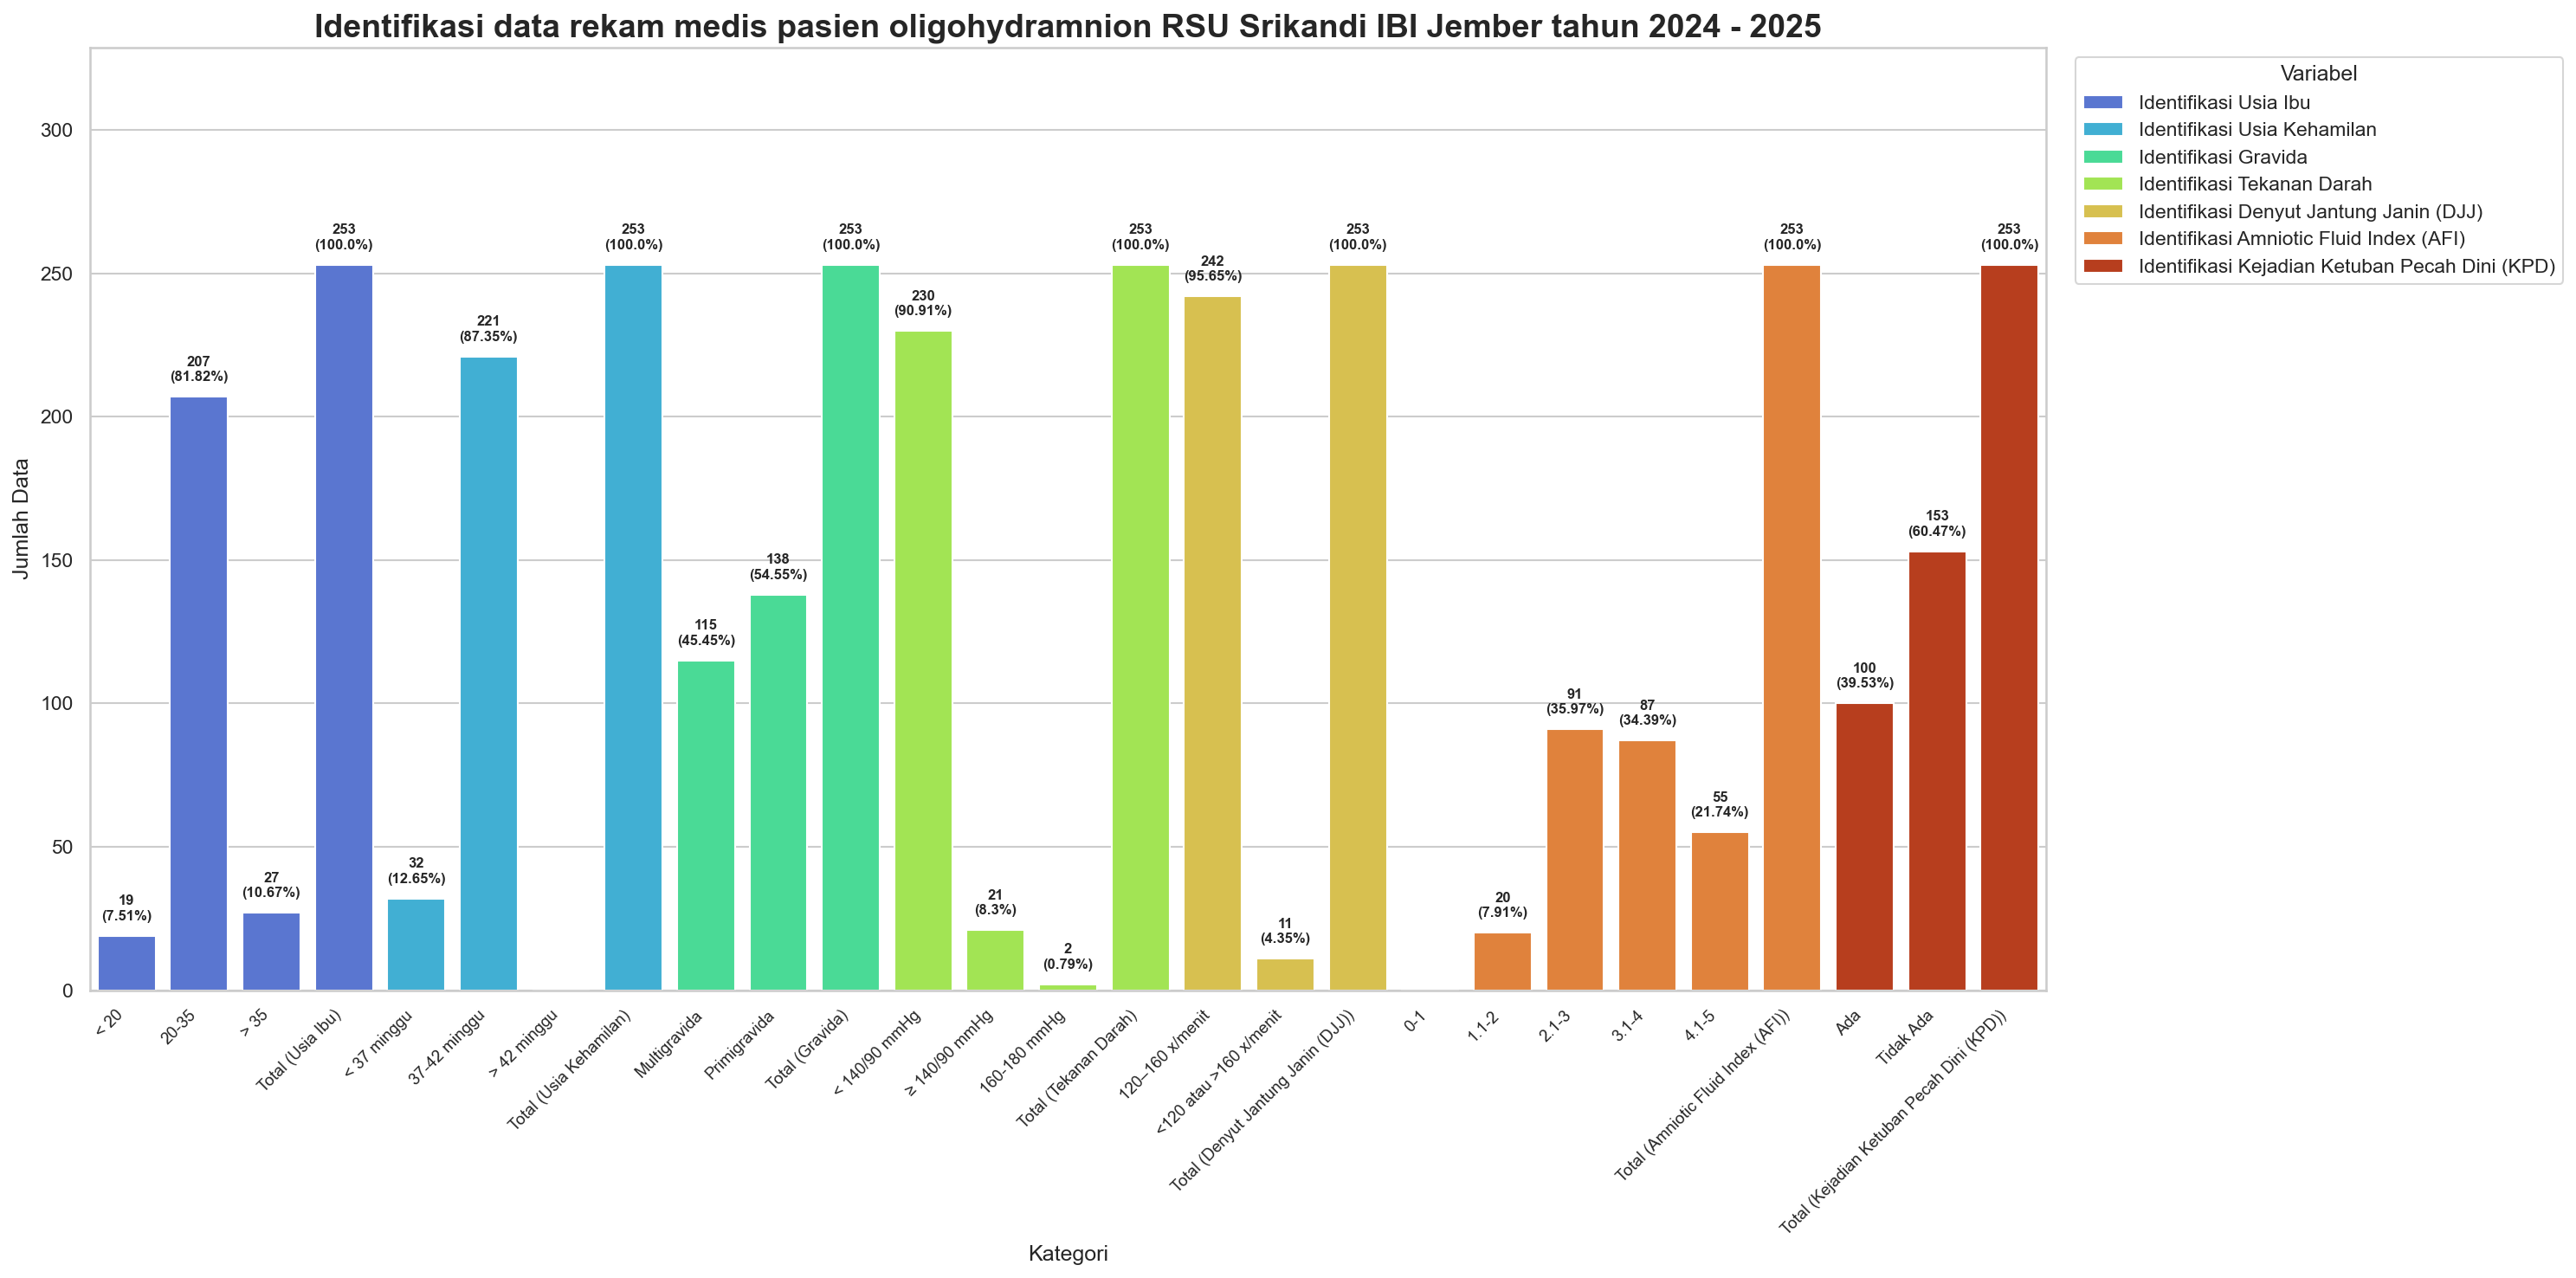

Total data mentah : 255
Data valid        : 253
Data invalid      : 2
Output tersimpan di folder outputs.


,No,Nomor RM,Usia Ibu,Usia Kehamilan,Gravida,Tekanan Darah,Denyut Jantung Janin,Nilai AFI,Kejadian KPD
0,1,054121,0.517241,0.842105,1.0,0.0,0.0,0.380805,1.0
1,2,065046,0.448276,0.877193,1.0,0.5,0.0,0.380805,1.0
2,3,078533,0.655172,0.842105,1.0,0.0,0.0,0.380805,1.0
3,4,083531,0.275862,0.877193,0.0,0.0,0.0,0.380805,1.0
4,5,079120,0.758621,0.771930,1.0,0.0,0.0,0.071207,0.0


In [2]:
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df = standardize_columns(raw_df)
transformed_df = transform_rows(raw_df)

valid_df = transformed_df.loc[transformed_df["Status Validasi"] == "valid"].copy()
invalid_df = transformed_df.loc[transformed_df["Status Validasi"] == "invalid"].copy()

# Visualisasi Identifikasi Data sebelum normalisasi
visualize_identifikasi(valid_df)

output_preprocessing, output_detail, min_values, max_values = build_normalized_outputs(valid_df)

invalid_export_columns = list(raw_df.columns) + [
    "Gravida Asli",
    "Denyut Jantung Janin Asli",
    "Sistolik",
    "Diastolik",
    "Status Validasi",
    "Alasan Invalid",
]
invalid_export_columns = [column for column in invalid_export_columns if column in invalid_df.columns]
invalid_export = invalid_df[invalid_export_columns].copy()

output_preprocessing = output_preprocessing.round(6)
output_detail = output_detail.round(6)
invalid_export.to_csv(OUTPUT_DIR / "output_data_invalid.csv", index=False, encoding="utf-8-sig")
output_preprocessing.to_csv(OUTPUT_DIR / "output_preprocessing.csv", index=False, encoding="utf-8-sig")
output_detail.to_csv(OUTPUT_DIR / "output_preprocessing_detail.csv", index=False, encoding="utf-8-sig")

metadata = {
    "total_rows_raw": int(len(raw_df)),
    "valid_rows": int(len(valid_df)),
    "invalid_rows": int(len(invalid_df)),
    "feature_columns": FEATURE_COLUMNS,
    "min_values": {column: float(value) for column, value in min_values.items()},
    "max_values": {column: float(value) for column, value in max_values.items()},
}

artifacts_dir = OUTPUT_DIR / "artifacts"
artifacts_dir.mkdir(exist_ok=True)
(artifacts_dir / "preprocessing_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

print(f"Total data mentah : {len(raw_df)}")
print(f"Data valid        : {len(valid_df)}")
print(f"Data invalid      : {len(invalid_df)}")
print("Output tersimpan di folder outputs.")
output_preprocessing.head()

## Training

In [3]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT_DIR = Path.cwd()
OUTPUT_DIR = ROOT_DIR / "outputs" / "k2"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"

FEATURE_COLUMNS = [
    "Usia Ibu",
    "Usia Kehamilan",
    "Gravida",
    "Tekanan Darah",
    "Denyut Jantung Janin",
    "Nilai AFI",
    "Kejadian KPD",
]
CLUSTER_LABELS = ["K1", "K2"]
CLUSTER_FILE_LABELS = ["K1", "K2"]
PARAMS = {
    "c": 2,
    "m": 2.0,
    "epsilon": 0.0001,
    "max_iter": 100,
    "seed": 42,
}

def load_training_inputs():
    preprocessing = pd.read_csv(OUTPUT_DIR / "output_preprocessing.csv", dtype={"Nomor RM": str})
    detail = pd.read_csv(OUTPUT_DIR / "output_preprocessing_detail.csv", dtype={"Nomor RM": str})
    metadata = json.loads((ARTIFACT_DIR / "preprocessing_metadata.json").read_text(encoding="utf-8"))
    preprocessing["No"] = preprocessing["No"].astype(int)
    detail["No"] = detail["No"].astype(int)
    return preprocessing, detail, metadata

def initialize_membership(n_samples, n_clusters, seed):
    rng = np.random.default_rng(seed)
    membership = rng.random((n_clusters, n_samples))
    membership /= membership.sum(axis=0, keepdims=True)
    return membership

def reorder_clusters(membership, centers):
    # Sort by Nilai AFI descending: High AFI (K1) comes first, Low AFI (K2) second
    order = np.argsort(-centers[:, FEATURE_COLUMNS.index("Nilai AFI")])
    return membership[order], centers[order], order

def compute_centers(data, membership, m):
    weights = membership ** m
    numerator = weights @ data
    denominator = weights.sum(axis=1, keepdims=True)
    return numerator / denominator

def compute_distances(data, centers):
    distances = np.linalg.norm(data[None, :, :] - centers[:, None, :], axis=2)
    return np.maximum(distances, 1e-10)

def update_membership(distances, m):
    exponent = 2.0 / (m - 1.0)
    membership = np.zeros_like(distances)
    for sample_index in range(distances.shape[1]):
        sample_distances = distances[:, sample_index]
        zero_mask = np.isclose(sample_distances, 0.0)
        if zero_mask.any():
            membership[zero_mask, sample_index] = 1.0 / zero_mask.sum()
            continue
        ratios = (sample_distances[:, None] / sample_distances[None, :]) ** exponent
        membership[:, sample_index] = 1.0 / ratios.sum(axis=1)
    return membership

def infer_cluster_labels(membership):
    return [CLUSTER_LABELS[index] for index in np.argmax(membership, axis=0)]

def denormalize(value, min_value, max_value):
    return float((value * (max_value - min_value)) + min_value)

def predict_action(cluster_number, usia_ibu_asli=None, gravida_asli=None):
    if cluster_number == 1: # K1
        return "Konservatif / Induksi / Partus spontan"
    # K2
    return "SC cito / SC"

def interpret_pc(value):
    if value >= 0.80: return "Sangat Baik"
    if value >= 0.60: return "Baik"
    if value >= 0.40: return "Cukup"
    return "Buruk"

def write_iteration_output(base_df, membership, max_delta, iteration, partition_coefficient, objective_function):
    export_df = base_df.copy()
    export_df["Iterasi"] = iteration
    export_df[["K1", "K2"]] = membership.T
    export_df["Hasil"] = infer_cluster_labels(membership)
    export_df["PC"] = partition_coefficient
    export_df["Fungsi Objektif"] = objective_function
    export_df["Max Selisih"] = max_delta
    export_df["No"] = export_df["No"].astype(int)
    export_df["Nomor RM"] = export_df["Nomor RM"].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(6)
    export_df.to_csv(
        OUTPUT_DIR / f"output_iterasi_t{iteration}.csv",
        index=False,
        encoding="utf-8-sig",
        lineterminator="\n",
        float_format="%.6f",
    )

def write_cluster_detail_file(cluster_number, cluster_label, squared_membership, feature_df, output_path):
    lines = [f"Klaster {cluster_number} {cluster_label}", ""]
    denominator_terms = [f"{value:.6f}" for value in squared_membership]
    denominator_value = float(squared_membership.sum())
    for feature_name in FEATURE_COLUMNS:
        feature_values = feature_df[feature_name].to_numpy(dtype=float)
        numerator_terms = [f"({weight:.6f} x {value:.6f})" for weight, value in zip(squared_membership, feature_values)]
        numerator_value = float(np.sum(squared_membership * feature_values))
        center_value = numerator_value / denominator_value if denominator_value else 0.0
        lines.extend([
            f"Fitur: {feature_name}",
            "V_kj = (Σ (μ_ik^2 x x_ij)) / (Σ μ_ik^2)",
            f"Pembilang = {' + '.join(numerator_terms)}",
            f"Pembilang = {numerator_value:.6f}",
            f"Penyebut = {' + '.join(denominator_terms)}",
            f"Penyebut = {denominator_value:.6f}",
            f"Hasil = {center_value:.6f}",
            "",
        ])
    output_path.write_text("\n".join(lines).strip() + "\n", encoding="utf-8")

In [4]:
preprocessing_df, detail_df, preprocessing_metadata = load_training_inputs()
base_df = preprocessing_df[["No", "Nomor RM"]].copy()
feature_df = preprocessing_df[FEATURE_COLUMNS].copy()
data = feature_df.to_numpy(dtype=float)

membership = initialize_membership(len(preprocessing_df), PARAMS["c"], PARAMS["seed"])

# Export Inisialisasi Matrix (Iterasi 0)
init_df = base_df.copy()
init_df[["μ1", "μ2"]] = membership.T
init_df["Total"] = init_df[["μ1", "μ2"]].sum(axis=1)
init_df = init_df.round(6)
init_df.to_csv(OUTPUT_DIR / "output_inisialisasi_matrix.csv", index=False, encoding="utf-8-sig")

pc_history = []
objective_history = []
delta_history = []
cluster_counts_history = []
centers = None

for iteration in range(1, PARAMS["max_iter"] + 1):
    centers_current = compute_centers(data, membership, PARAMS["m"])
    membership, centers_current, _ = reorder_clusters(membership, centers_current)
    distances = compute_distances(data, centers_current)
    objective_function = float(np.sum((membership ** PARAMS["m"]) * (distances ** 2)))
    updated_membership = update_membership(distances, PARAMS["m"])
    updated_centers = compute_centers(data, updated_membership, PARAMS["m"])
    updated_membership, updated_centers, _ = reorder_clusters(updated_membership, updated_centers)
    
    max_delta = float(np.max(np.abs(updated_membership - membership)))
    partition_coefficient = float(np.sum(updated_membership ** 2) / len(preprocessing_df))
    
    write_iteration_output(base_df, updated_membership, max_delta, iteration, partition_coefficient, objective_function)
    iteration_labels = infer_cluster_labels(updated_membership)
    iteration_counts = pd.Series(iteration_labels).value_counts().reindex(CLUSTER_LABELS, fill_value=0).to_dict()
    pc_history.append(partition_coefficient)
    objective_history.append(objective_function)
    delta_history.append(max_delta)
    cluster_counts_history.append(iteration_counts)
    
    membership = updated_membership
    centers = updated_centers
    if max_delta < PARAMS["epsilon"]: break

final_distances = compute_distances(data, centers)
final_squared = membership ** 2
final_labels = infer_cluster_labels(membership)

usia_min = preprocessing_metadata["min_values"]["Usia Ibu"]
usia_max = preprocessing_metadata["max_values"]["Usia Ibu"]
usia_asli = preprocessing_df["Usia Ibu"].apply(lambda value: denormalize(value, usia_min, usia_max))
gravidas_asli = detail_df["Gravida Asli"].fillna(0)

prediksi_tindakan = [
    predict_action(index + 1, usia_asli.iloc[row_index], gravidas_asli.iloc[row_index])
    for row_index, index in enumerate(np.argmax(membership, axis=0))
]

output_keanggotaan = base_df.copy()
output_keanggotaan[["μ1", "μ2"]] = membership.T
output_keanggotaan = output_keanggotaan.round(6)
output_keanggotaan.to_csv(OUTPUT_DIR / "output_keanggotaan.csv", index=False, encoding="utf-8-sig")

output_euclidean = base_df.copy()
output_euclidean[["d1", "d2"]] = final_distances.T
output_euclidean = output_euclidean.round(6)
output_euclidean.to_csv(OUTPUT_DIR / "output_euclidean.csv", index=False, encoding="utf-8-sig")

output_partition = base_df.copy()
output_partition[["K1", "K2"]] = final_squared.T
output_partition = output_partition.round(6)
output_partition.to_csv(OUTPUT_DIR / "output_partition_coefficient.csv", index=False, encoding="utf-8-sig")

output_centers = pd.DataFrame(centers, columns=FEATURE_COLUMNS)
output_centers.insert(0, "Klaster", CLUSTER_FILE_LABELS)
output_centers = output_centers.round(6)
output_centers.to_csv(OUTPUT_DIR / "output_pusat_klaster.csv", index=False, encoding="utf-8-sig")

for cluster_index, cluster_label in enumerate(CLUSTER_LABELS, start=1):
    write_cluster_detail_file(
        cluster_number=cluster_index,
        cluster_label=cluster_label,
        squared_membership=final_squared[cluster_index - 1],
        feature_df=feature_df,
        output_path=OUTPUT_DIR / f"output_pusat_klaster_K{cluster_index}.txt",
    )

output_final = base_df.copy()
output_final[["K1", "K2"]] = membership.T
output_final[["μ1²", "μ2²"]] = final_squared.T
output_final["Hasil"] = final_labels
output_final["Prediksi Tindakan"] = prediksi_tindakan
output_final["Tindakan Aktual"] = detail_df["Tindakan"].fillna("")
for column in ["K1", "K2", "μ1²", "μ2²"]:
    output_final[column] = pd.to_numeric(output_final[column], errors="coerce")
output_final["No"] = output_final["No"].astype(int)
output_final["Nomor RM"] = output_final["Nomor RM"].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(6)
output_final.to_csv(
    OUTPUT_DIR / "output_fcm_final.csv",
    index=False,
    encoding="utf-8-sig",
    lineterminator="\n",
    float_format="%.6f",
)

fcm_model = {
    "feature_columns": FEATURE_COLUMNS,
    "cluster_labels": {str(index + 1): label for index, label in enumerate(CLUSTER_LABELS)},
    "min_values": preprocessing_metadata["min_values"],
    "max_values": preprocessing_metadata["max_values"],
    "centers": centers.tolist(),
    "params": PARAMS,
    "pc_final": pc_history[-1],
    "iterations_run": len(pc_history),
}
(ARTIFACT_DIR / "fcm_model.json").write_text(json.dumps(fcm_model, indent=2), encoding="utf-8")

training_summary = {
    "valid_rows": int(len(preprocessing_df)),
    "iterations_run": len(pc_history),
    "pc_final": pc_history[-1],
    "cluster_counts": pd.Series(final_labels).value_counts().reindex(CLUSTER_LABELS, fill_value=0).to_dict(),
}
(ARTIFACT_DIR / "training_summary.json").write_text(json.dumps(training_summary, indent=2), encoding="utf-8")

iteration_summary = pd.DataFrame({
    "Iterasi": list(range(1, len(pc_history) + 1)),
    "PC": pc_history,
    "Fungsi Objektif": objective_history,
    "Interpretasi": [interpret_pc(value) for value in pc_history],
    "Max Selisih": delta_history,
})
for cluster_label in CLUSTER_LABELS:
    iteration_summary[cluster_label] = [int(counts[cluster_label]) for counts in cluster_counts_history]
iteration_summary.to_csv(
    OUTPUT_DIR / "output_ringkasan_iterasi.csv",
    index=False,
    encoding="utf-8-sig",
    lineterminator="\n",
    float_format="%.6f",
)

objective_summary = pd.DataFrame({
    "Iterasi": list(range(1, len(objective_history) + 1)),
    "Fungsi Objektif": objective_history
})
objective_summary.to_csv(
    OUTPUT_DIR / "output_fungsi_objektif.csv",
    index=False,
    encoding="utf-8-sig",
    lineterminator="\n",
    float_format="%.6f",
)

pc_artifact = {
    "pc_history": pc_history,
    "objective_history": objective_history,
    "delta_history": delta_history,
    "iterations_run": len(pc_history),
    "pc_final": pc_history[-1],
    "objective_final": objective_history[-1],
}
(ARTIFACT_DIR / "pc_history.json").write_text(json.dumps(pc_artifact, indent=2), encoding="utf-8")

print(f"Iterasi selesai : {len(pc_history)}")
print(f"PC final        : {pc_history[-1]:.6f}")
output_final.head()

Iterasi selesai : 68
PC final        : 0.660145


,No,Nomor RM,K1,K2,μ1²,μ2²,Hasil,Prediksi Tindakan,Tindakan Aktual
0,1,054121,0.206137,0.793863,0.042492,0.630219,K2,SC cito / SC,sc
1,2,065046,0.286040,0.713960,0.081819,0.509739,K2,SC cito / SC,sc
2,3,078533,0.200649,0.799351,0.040260,0.638963,K2,SC cito / SC,sc
3,4,083531,0.886686,0.113314,0.786213,0.012840,K1,Konservatif / Induksi / Partus spontan,sc
4,5,079120,0.256447,0.743553,0.065765,0.552871,K2,SC cito / SC,sc


## Testing

In [5]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd

ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs" / "k2"
TESTING_DIR = OUTPUT_DIR / "testing"
TESTING_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"

RAW_TEST_PATH = DATA_DIR / "data_testing_contoh.csv"
FEATURE_COLUMNS = [
    "Usia Ibu",
    "Usia Kehamilan",
    "Gravida",
    "Tekanan Darah",
    "Denyut Jantung Janin",
    "Nilai AFI",
    "Kejadian KPD",
]
COLUMN_ALIASES = {
    "Kejadian Ketuban Pecah Dini": "Kejadian KPD",
    "Kejadian kpd": "Kejadian KPD",
    "Nomor Rekam Medis": "Nomor RM",
}
CLUSTER_LABELS = ["K1", "K2"]

def clean_text(value):
    if pd.isna(value): return ""
    text = str(value).strip()
    if not text or text.lower() == "nan": return ""
    return text

def remove_mow_text(value):
    text = clean_text(value)
    if not text: return ""
    parts = [part.strip() for part in text.replace("+", ",").split(",")]
    parts = [part for part in parts if part and part.lower() != "mow"]
    return ", ".join(parts)

def parse_numeric(value):
    text = clean_text(value)
    if not text: return None
    text = text.replace(",", ".")
    try: return float(text)
    except ValueError: return None

def normalize_rm(value):
    text = clean_text(value)
    if not text: return ""
    compact = text.replace(" ", "")
    numeric = compact.replace(".0", "")
    if numeric.isdigit(): return numeric.zfill(6)
    return compact

def parse_range_numeric(value):
    text = clean_text(value)
    if not text: return None
    text = text.replace("–", "-").replace("—", "-").replace(" ", "")
    if "-" in text:
        parts = [part for part in text.split("-") if part]
        numbers = []
        for part in parts:
            try: numbers.append(float(part.replace(",", ".")))
            except ValueError: return None
        return float(sum(numbers) / len(numbers)) if numbers else None
    return parse_numeric(text)

def parse_blood_pressure(value):
    text = clean_text(value)
    if not text: return None, None, None
    text = text.replace(" ", "")
    match = re.match(r"^(\d{2,3})/(\d{2,3})$", text)
    if not match: return None, None, None
    systolic = int(match.group(1))
    diastolic = int(match.group(2))
    if 160 <= systolic <= 180: attr = 3
    elif systolic >= 140 or diastolic >= 90: attr = 2
    else: attr = 1
    return attr, systolic, diastolic

def transform_gravida(value):
    number = parse_numeric(value)
    if number is None: return None, None
    return (1 if number == 1 else 2), float(number)

def transform_djj(value):
    number = parse_numeric(value)
    if number is None: return None, None
    if 120 <= number <= 160: attr = 0
    else: attr = 1
    return attr, float(number)

def transform_kpd(value):
    text = clean_text(value).lower()
    if not text: return None
    if text == "tidak": return 1
    if text == "ada": return 0
    return None

def standardize_columns(df):
    renamed = []
    for column in df.columns:
        clean_column = clean_text(column)
        renamed.append(COLUMN_ALIASES.get(clean_column, clean_column or column))
    df = df.copy()
    df.columns = renamed
    for column in ["No", "Nomor RM", *FEATURE_COLUMNS, "Tindakan"]:
        if column not in df.columns: df[column] = np.nan
    return df

def transform_rows(raw_df):
    records = []
    original_columns = list(raw_df.columns)
    for _, row in raw_df.iterrows():
        record = {column: row.get(column, np.nan) for column in original_columns}
        reasons = []
        no_value = parse_numeric(row.get("No"))
        nomor_rm = normalize_rm(row.get("Nomor RM"))
        usia_ibu = parse_numeric(row.get("Usia Ibu"))
        usia_kehamilan = parse_range_numeric(row.get("Usia Kehamilan"))
        gravida_attr, gravida_raw = transform_gravida(row.get("Gravida"))
        tekanan_attr, systolic, diastolic = parse_blood_pressure(row.get("Tekanan Darah"))
        djj_attr, djj_raw = transform_djj(row.get("Denyut Jantung Janin"))
        nilai_afi = parse_numeric(row.get("Nilai AFI"))
        kpd_attr = transform_kpd(row.get("Kejadian KPD"))
        tindakan_val = remove_mow_text(row.get("Tindakan"))
        if no_value is None: reasons.append("No kosong")
        if not nomor_rm: reasons.append("Nomor RM kosong")
        if usia_ibu is None: reasons.append("Usia Ibu tidak valid/kosong")
        if usia_kehamilan is None: reasons.append("Usia Kehamilan tidak valid/kosong")
        if gravida_attr is None: reasons.append("Gravida tidak valid/kosong")
        if tekanan_attr is None: reasons.append("Tekanan Darah tidak valid/kosong")
        if djj_attr is None: reasons.append("Denyut Jantung Janin tidak valid/kosong")
        if nilai_afi is None: reasons.append("Nilai AFI tidak valid/kosong")
        if kpd_attr is None: reasons.append("Kejadian KPD tidak valid/kosong")
        if not tindakan_val: reasons.append("Tindakan tidak valid/kosong")
        record["No"] = int(no_value) if no_value is not None else np.nan
        record["Nomor RM"] = nomor_rm or np.nan
        record["Usia Ibu"] = usia_ibu if usia_ibu is not None else np.nan
        record["Usia Kehamilan"] = usia_kehamilan if usia_kehamilan is not None else np.nan
        record["Gravida"] = gravida_attr if gravida_attr is not None else np.nan
        record["Tekanan Darah"] = tekanan_attr if tekanan_attr is not None else np.nan
        record["Denyut Jantung Janin"] = djj_attr if djj_attr is not None else np.nan
        record["Nilai AFI"] = nilai_afi if nilai_afi is not None else np.nan
        record["Kejadian KPD"] = kpd_attr if kpd_attr is not None else np.nan
        record["Tindakan"] = tindakan_val or np.nan
        record["Gravida Asli"] = gravida_raw if gravida_raw is not None else np.nan
        record["Denyut Jantung Janin Asli"] = djj_raw if djj_raw is not None else np.nan
        record["Sistolik"] = systolic if systolic is not None else np.nan
        record["Diastolik"] = diastolic if diastolic is not None else np.nan
        record["Status Validasi"] = "valid" if not reasons else "invalid"
        record["Alasan Invalid"] = "; ".join(reasons)
        records.append(record)
    return pd.DataFrame(records)

def normalize_dataframe(valid_df, min_values, max_values):
    normalized = valid_df.copy()
    for column in FEATURE_COLUMNS:
        min_v = min_values[column]
        max_v = max_values[column]
        if max_v == min_v: normalized[column] = 0.0
        else: normalized[column] = (normalized[column].astype(float) - min_v) / (max_v - min_v)
    return normalized

def compute_distances(data, centers):
    distances = np.linalg.norm(data[None, :, :] - centers[:, None, :], axis=2)
    return np.maximum(distances, 1e-10)

def update_membership(distances, m=2.0):
    exponent = 2.0 / (m - 1.0)
    membership = np.zeros_like(distances)
    for sample_index in range(distances.shape[1]):
        sample_distances = distances[:, sample_index]
        zero_mask = np.isclose(sample_distances, 0.0)
        if zero_mask.any():
            membership[zero_mask, sample_index] = 1.0 / zero_mask.sum()
            continue
        ratios = (sample_distances[:, None] / sample_distances[None, :]) ** exponent
        membership[:, sample_index] = 1.0 / ratios.sum(axis=1)
    return membership

def predict_action(cluster_number, usia_ibu_asli=None, gravida_asli=None):
    if cluster_number == 1: return "Konservatif / Induksi / Partus spontan"
    return "SC cito / SC"

In [6]:
model = json.loads((ARTIFACT_DIR / "fcm_model.json").read_text(encoding="utf-8"))
raw_df = pd.read_csv(RAW_TEST_PATH)
raw_df = standardize_columns(raw_df)
transformed_df = transform_rows(raw_df)

valid_df = transformed_df.loc[transformed_df["Status Validasi"] == "valid"].copy()
invalid_df = transformed_df.loc[transformed_df["Status Validasi"] == "invalid"].copy()

invalid_export_columns = list(raw_df.columns) + ["Gravida Asli", "Denyut Jantung Janin Asli", "Sistolik", "Diastolik", "Status Validasi", "Alasan Invalid"]
invalid_export_columns = [column for column in invalid_export_columns if column in invalid_df.columns]
invalid_df[invalid_export_columns].to_csv(TESTING_DIR / "output_testing_invalid.csv", index=False, encoding="utf-8-sig")

normalized_valid = normalize_dataframe(valid_df, model["min_values"], model["max_values"])
output_preprocessing = normalized_valid[["No", "Nomor RM", *FEATURE_COLUMNS]].copy().round(6)
output_preprocessing["No"] = output_preprocessing["No"].astype(int)
output_preprocessing["Nomor RM"] = output_preprocessing["Nomor RM"].astype(str)
output_preprocessing.to_csv(TESTING_DIR / "output_testing_preprocessing.csv", index=False, encoding="utf-8-sig")

base_df = output_preprocessing[["No", "Nomor RM"]].copy()
data = output_preprocessing[FEATURE_COLUMNS].to_numpy(dtype=float)
centers = np.array(model["centers"], dtype=float)
distances = compute_distances(data, centers)
membership = update_membership(distances, m=float(model["params"]["m"]))
squared = membership ** 2
labels = [CLUSTER_LABELS[index] for index in np.argmax(membership, axis=0)]

output_keanggotaan = base_df.copy()
output_keanggotaan[["μ1", "μ2"]] = membership.T
output_keanggotaan = output_keanggotaan.round(6)
output_keanggotaan.to_csv(TESTING_DIR / "output_testing_keanggotaan.csv", index=False, encoding="utf-8-sig")

output_euclidean = base_df.copy()
output_euclidean[["d1", "d2"]] = distances.T
output_euclidean = output_euclidean.round(6)
output_euclidean.to_csv(TESTING_DIR / "output_testing_euclidean.csv", index=False, encoding="utf-8-sig")

prediksi_tindakan = [
    predict_action(index + 1, valid_df.iloc[row_index]["Usia Ibu"], valid_df.iloc[row_index]["Gravida Asli"])
    for row_index, index in enumerate(np.argmax(membership, axis=0))
]

output_final = base_df.copy()
output_final[["K1", "K2"]] = membership.T
output_final[["μ1²", "μ2²"]] = squared.T
output_final["Hasil"] = labels
output_final["Prediksi Tindakan"] = prediksi_tindakan
output_final = output_final.round(6)
output_final.to_csv(TESTING_DIR / "output_testing_final.csv", index=False, encoding="utf-8-sig")

print(f"Data testing valid   : {len(valid_df)}")
print(f"Data testing invalid : {len(invalid_df)}")
output_final.head()

Data testing valid   : 15
Data testing invalid : 0


,No,Nomor RM,K1,K2,μ1²,μ2²,Hasil,Prediksi Tindakan
0,241,083790,0.661156,0.338844,0.437128,0.114815,K1,Konservatif / Induksi / Partus spontan
1,242,084788,0.670544,0.329456,0.449629,0.108541,K1,Konservatif / Induksi / Partus spontan
2,243,078086,0.278302,0.721698,0.077452,0.520848,K2,SC cito / SC
3,244,084816,0.251338,0.748662,0.063171,0.560495,K2,SC cito / SC
4,245,084195,0.250578,0.749422,0.062789,0.561634,K2,SC cito / SC


## Evaluasi

In [7]:
import json
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

ROOT_DIR = Path.cwd()
OUTPUT_DIR = ROOT_DIR / "outputs" / "k2"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
EVALUATION_DIR = OUTPUT_DIR / "evaluasi"
EVALUATION_DIR.mkdir(exist_ok=True)

FEATURE_COLUMNS = [
    "Usia Ibu",
    "Usia Kehamilan",
    "Gravida",
    "Tekanan Darah",
    "Denyut Jantung Janin",
    "Nilai AFI",
    "Kejadian KPD",
]
CLUSTER_LABELS = ["K1", "K2"]
CLUSTER_COLORS = {
    "K1": "#40DF00",
    "K2": "#F44336",
}

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [8]:
def interpret_pc(value):
    if value >= 0.80: return "Sangat Baik"
    if value >= 0.60: return "Baik"
    if value >= 0.40: return "Cukup"
    return "Buruk"

def clean_action_text(value):
    text = str(value or "").strip().lower()
    text = text.replace("  ", " ").replace(", ", ",")
    parts = [part.strip() for part in text.replace("+", ",").split(",")]
    parts = [part for part in parts if part and part != "mow"]
    return ",".join(parts)

def summarize_prediction(value):
    return clean_action_text(value)

def classify_alignment(cluster_label, actual_action):
    actual = clean_action_text(actual_action)
    if not actual: return "Perlu Review"
    is_surgical = any(keyword in actual for keyword in ["sc", "sctp", "sectio", "cito", "od,sc", "od, sc"])
    is_vaginal = any(keyword in actual for keyword in ["partus", "spontan", "pervaginam", "normal"])
    if cluster_label == "K1": return "Selaras" if is_vaginal else "Perlu Review"
    return "Selaras" if is_surgical else "Perlu Review"

def save_matplotlib_figure(path):
    plt.savefig(path)
    plt.show()
    plt.close()

def save_plotly_figure(fig, path, height=560):
    path = Path(path)
    fig.write_html(path, include_plotlyjs="cdn")
    try:
        from IPython.display import IFrame, display
        display(IFrame(src=path.resolve().as_uri(), width="100%", height=height))
    except Exception: print(f"Visualisasi tersimpan: {path}")

def catmull_rom_smooth(x_values, y_values, samples_per_segment=30):
    points = np.column_stack([x_values, y_values]).astype(float)
    if len(points) < 4: return np.array(x_values, dtype=float), np.array(y_values, dtype=float)
    padded = np.vstack([points[0], points, points[-1]])
    smooth_points = []
    for index in range(1, len(padded) - 2):
        p0, p1, p2, p3 = padded[index - 1], padded[index], padded[index + 1], padded[index + 2]
        t_values = np.linspace(0, 1, samples_per_segment, endpoint=False)
        for t in t_values:
            t2, t3 = t * t, t * t * t
            point = 0.5 * ((2 * p1) + (-p0 + p2) * t + (2 * p0 - 5 * p1 + 4 * p2 - p3) * t2 + (-p0 + 3 * p1 - 3 * p2 + p3) * t3)
            smooth_points.append(point)
    smooth_points.append(points[-1])
    smooth_points = np.array(smooth_points)
    return smooth_points[:, 0], smooth_points[:, 1]

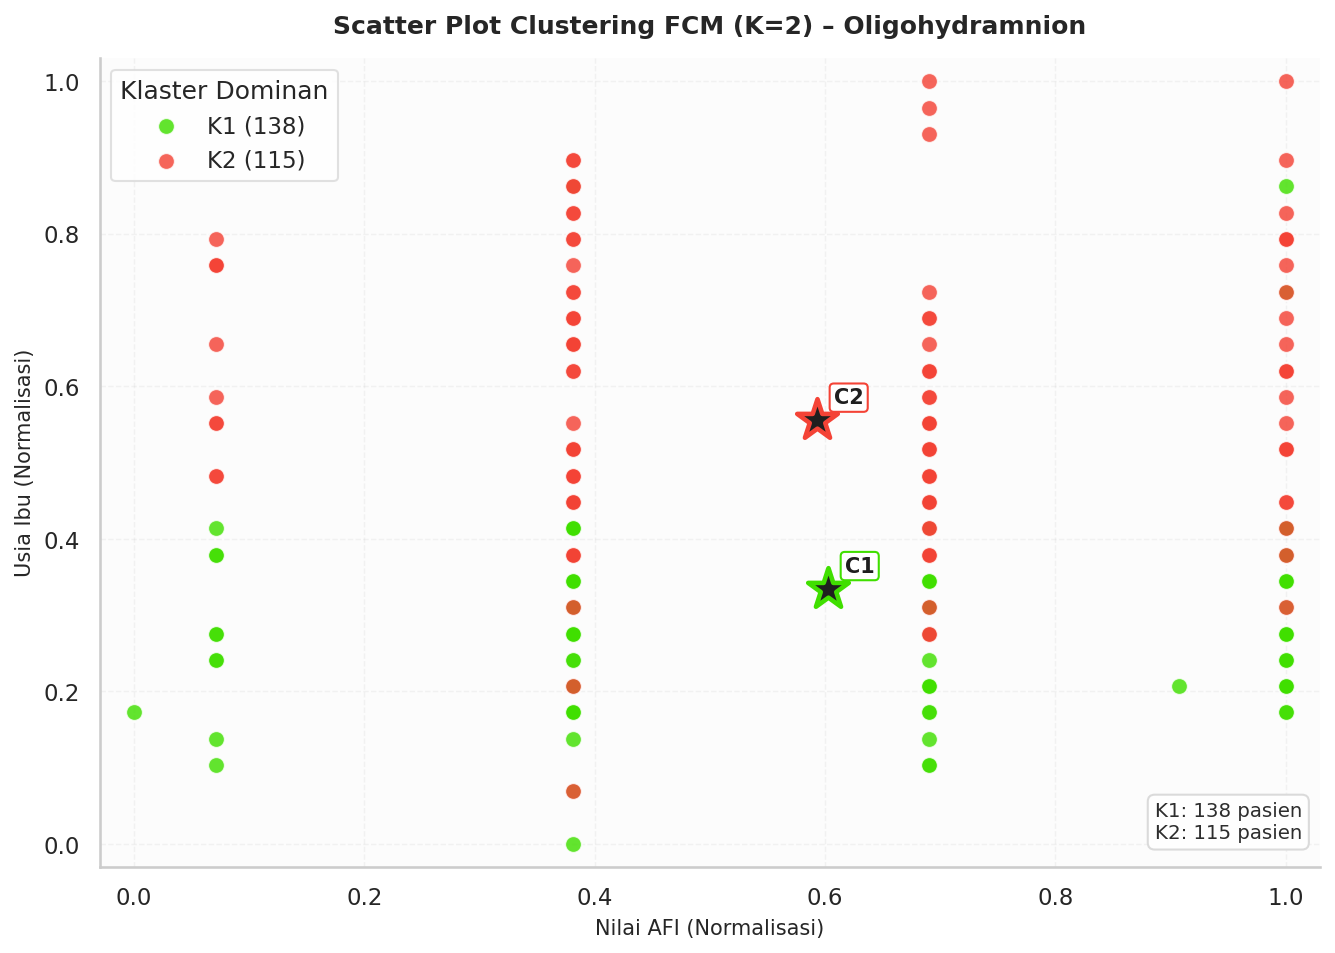

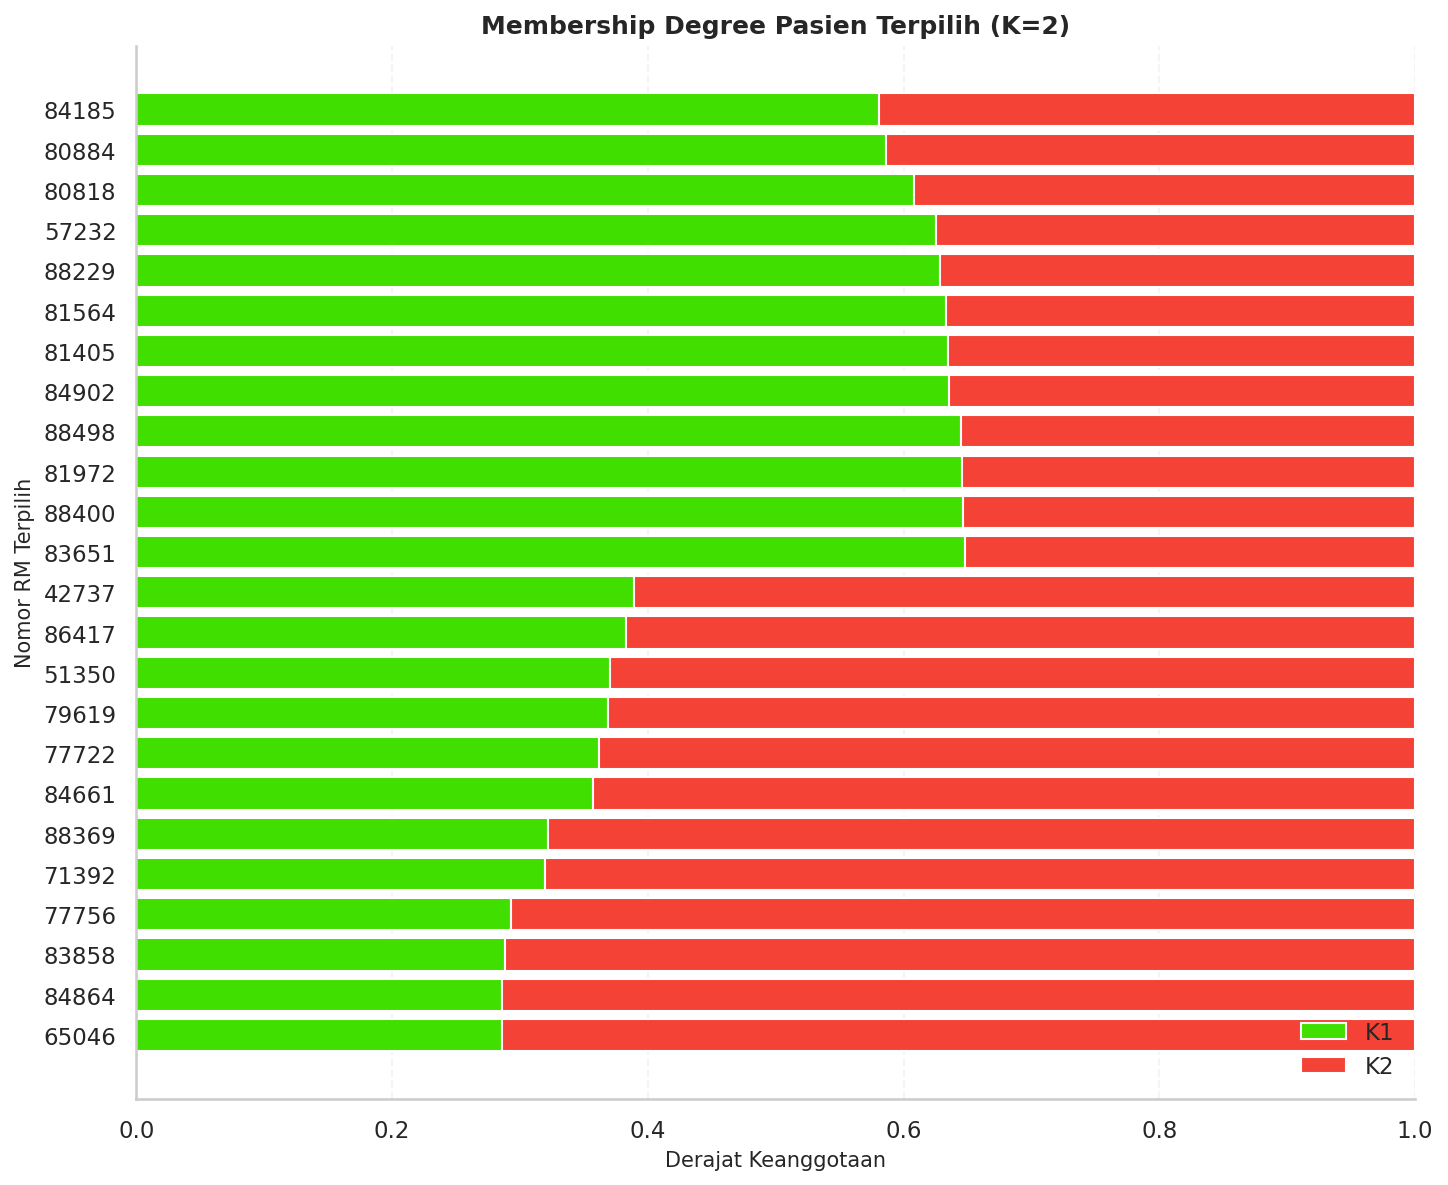

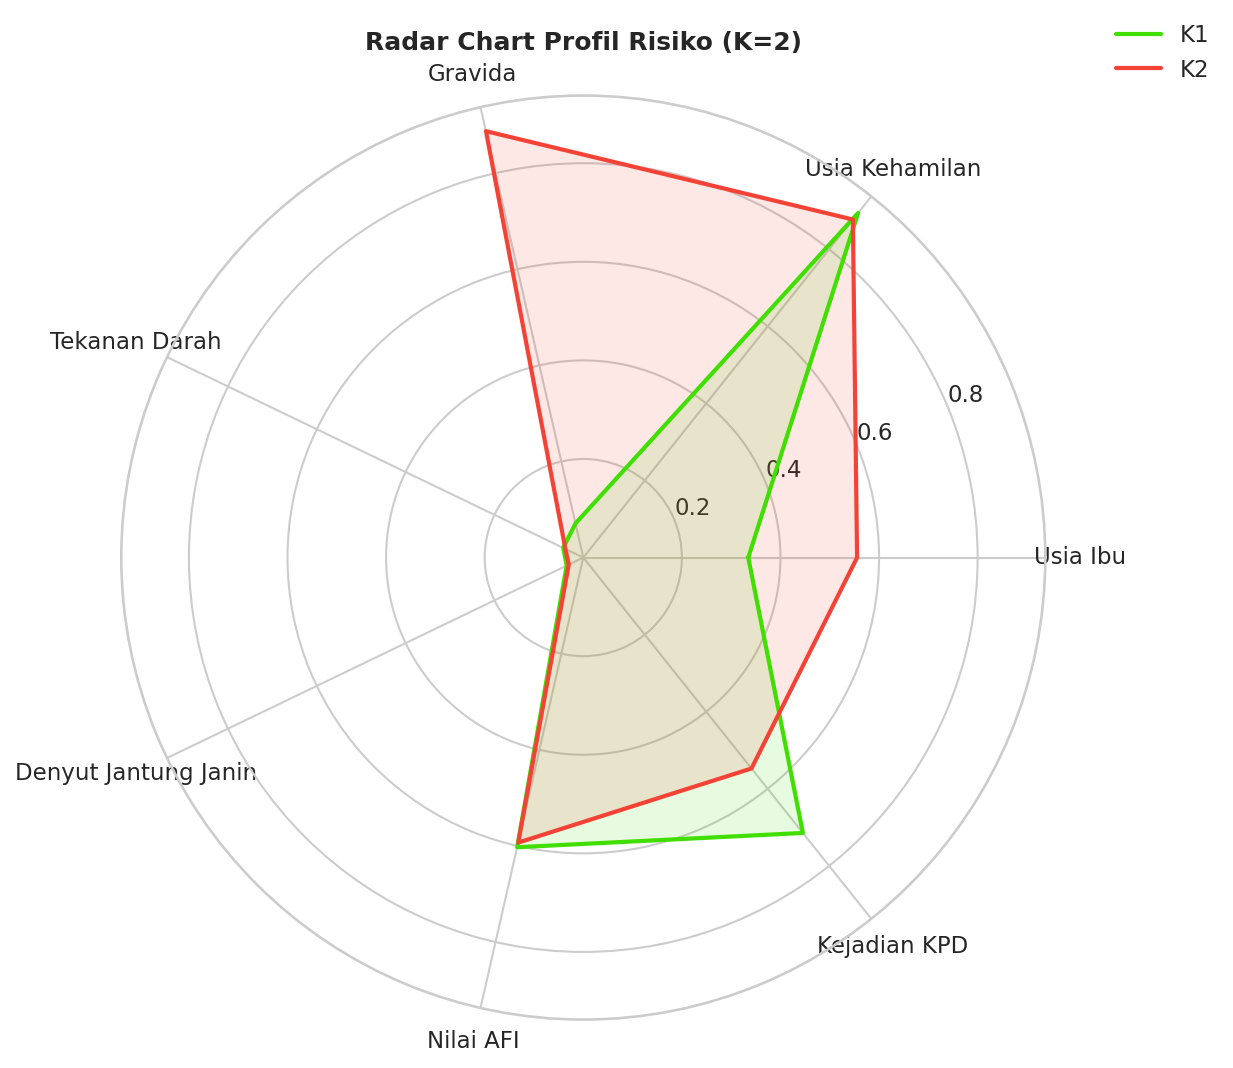

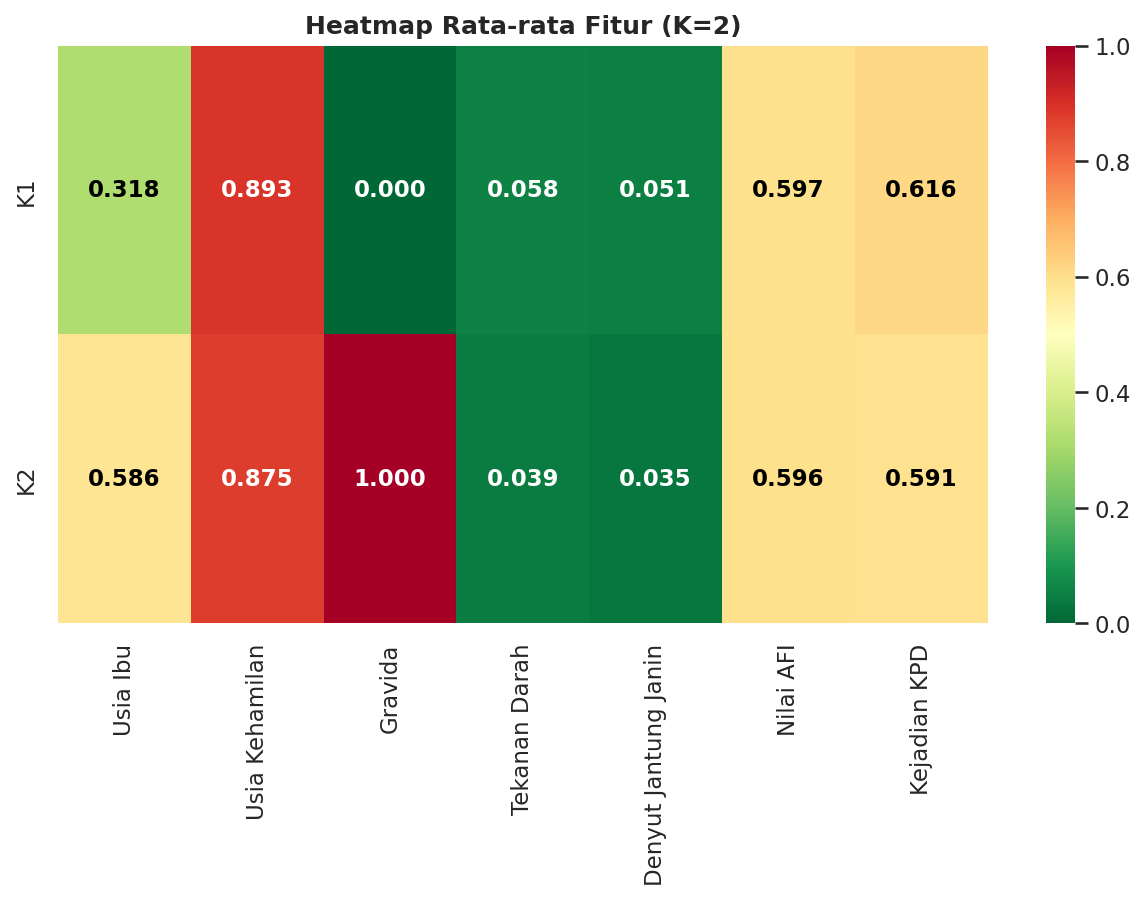

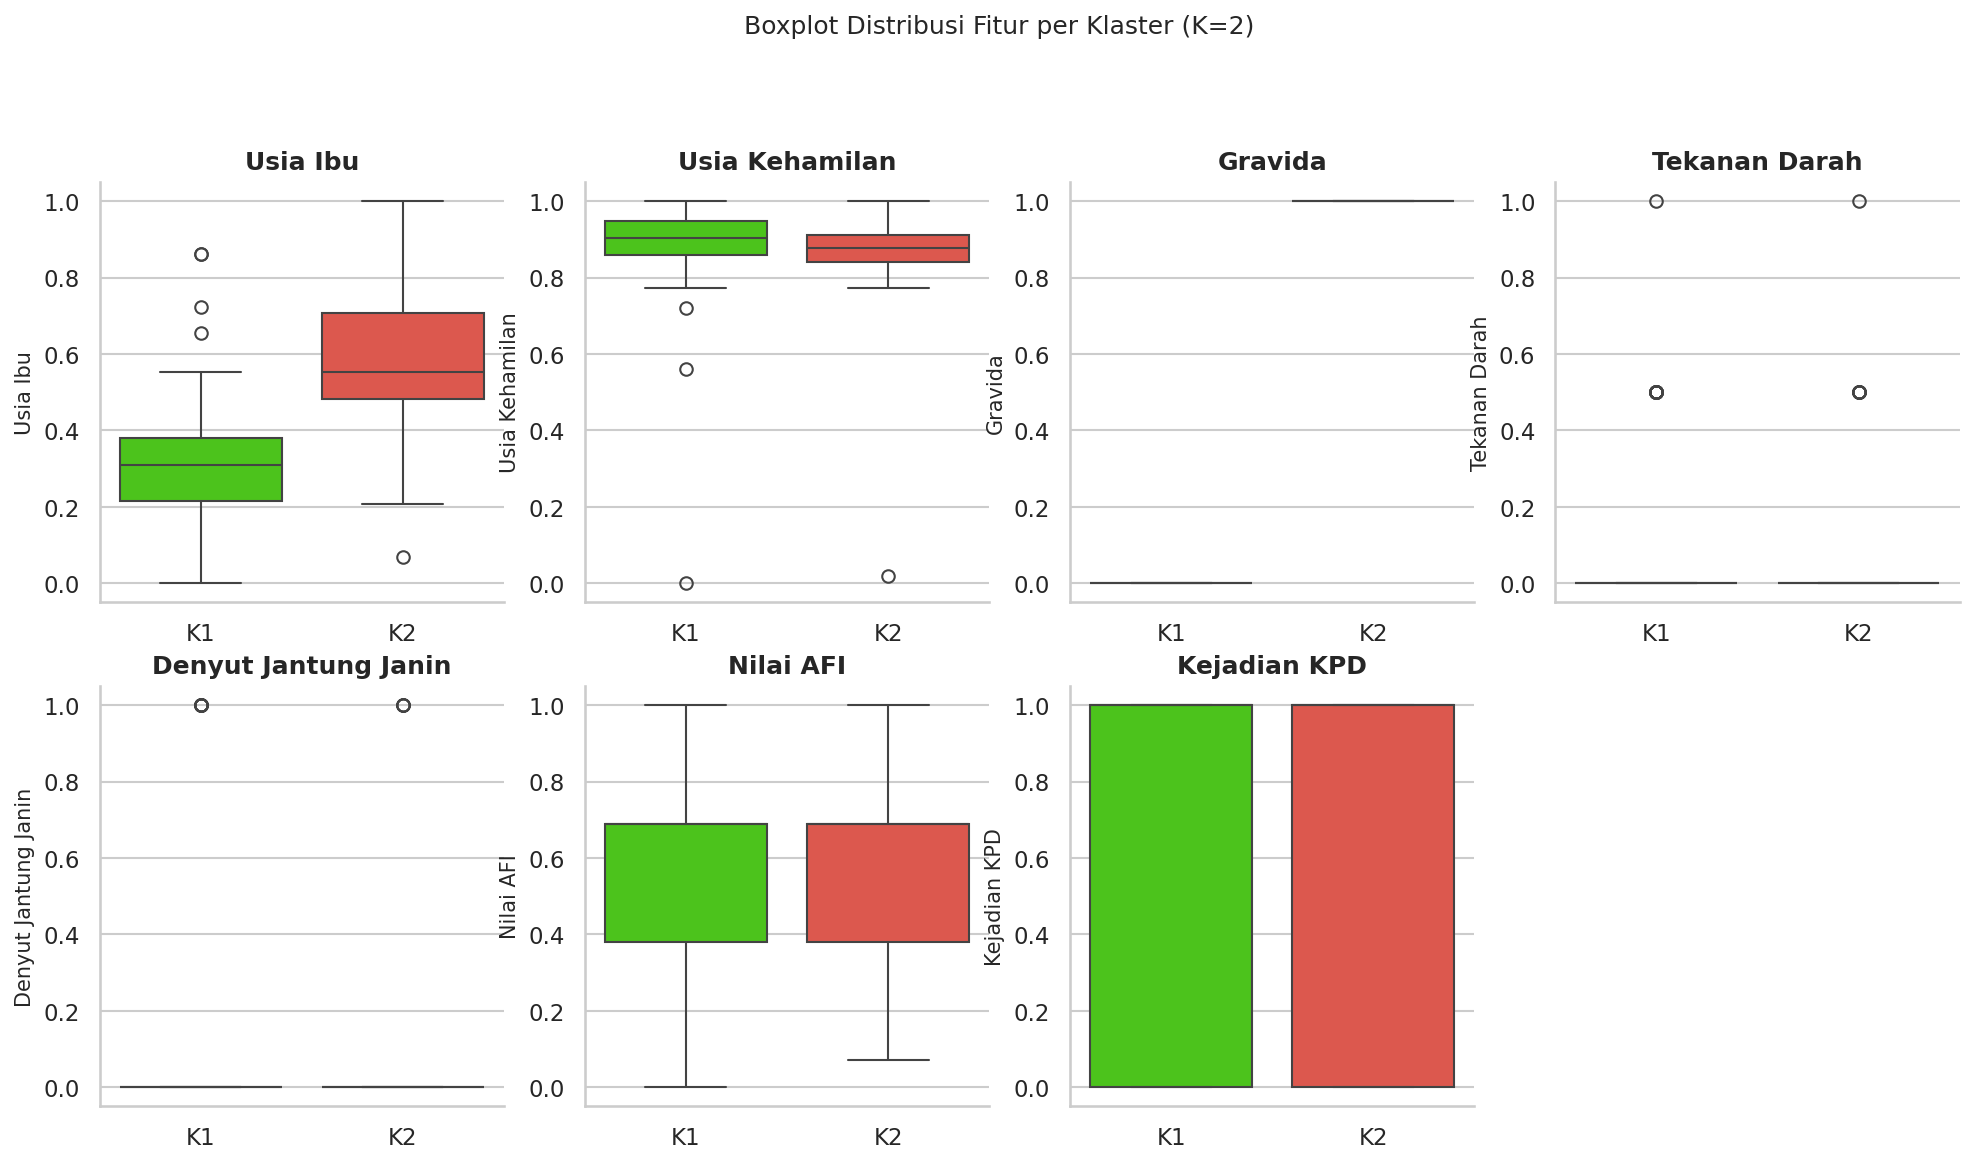

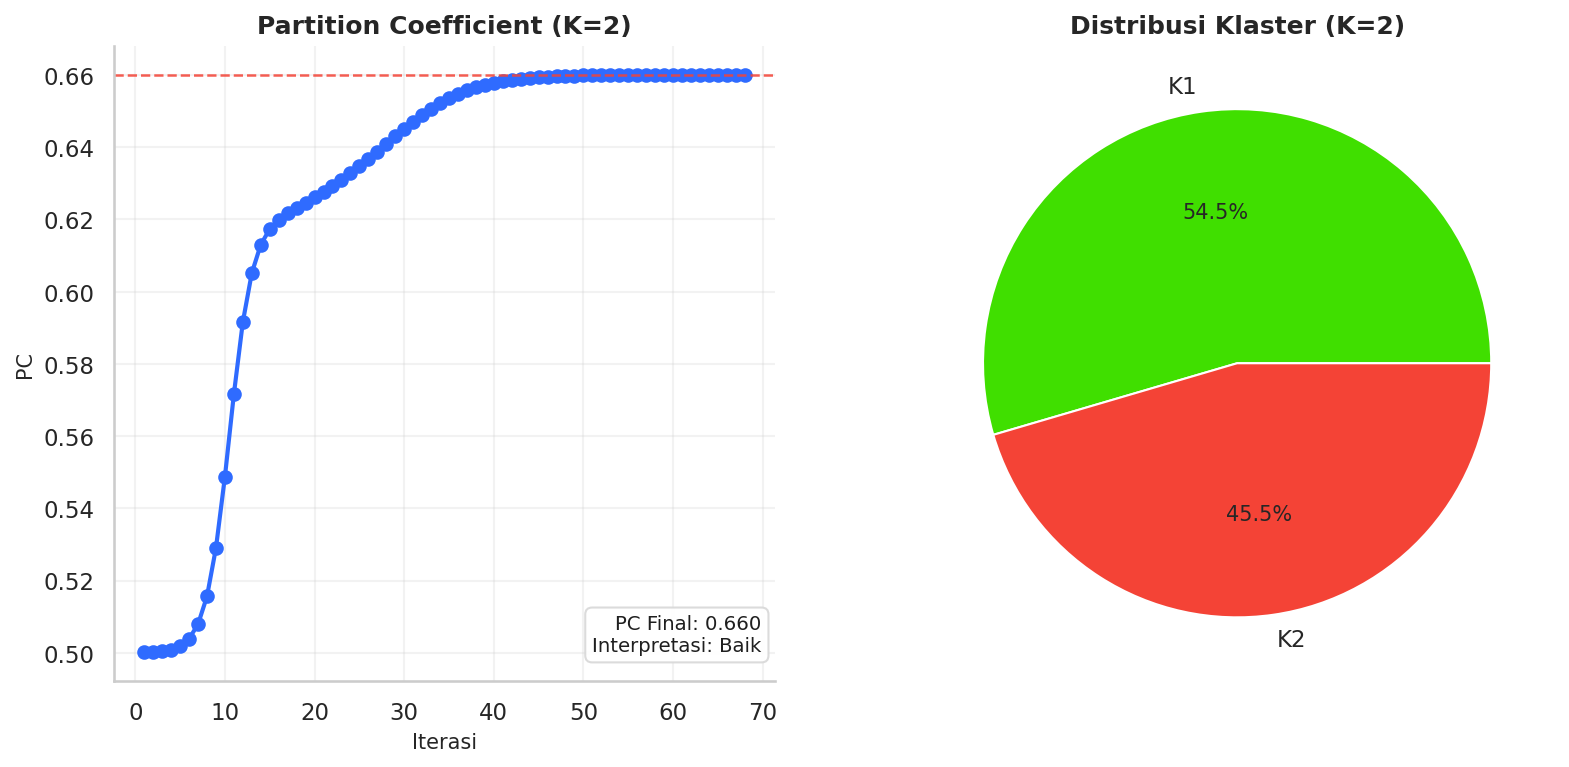

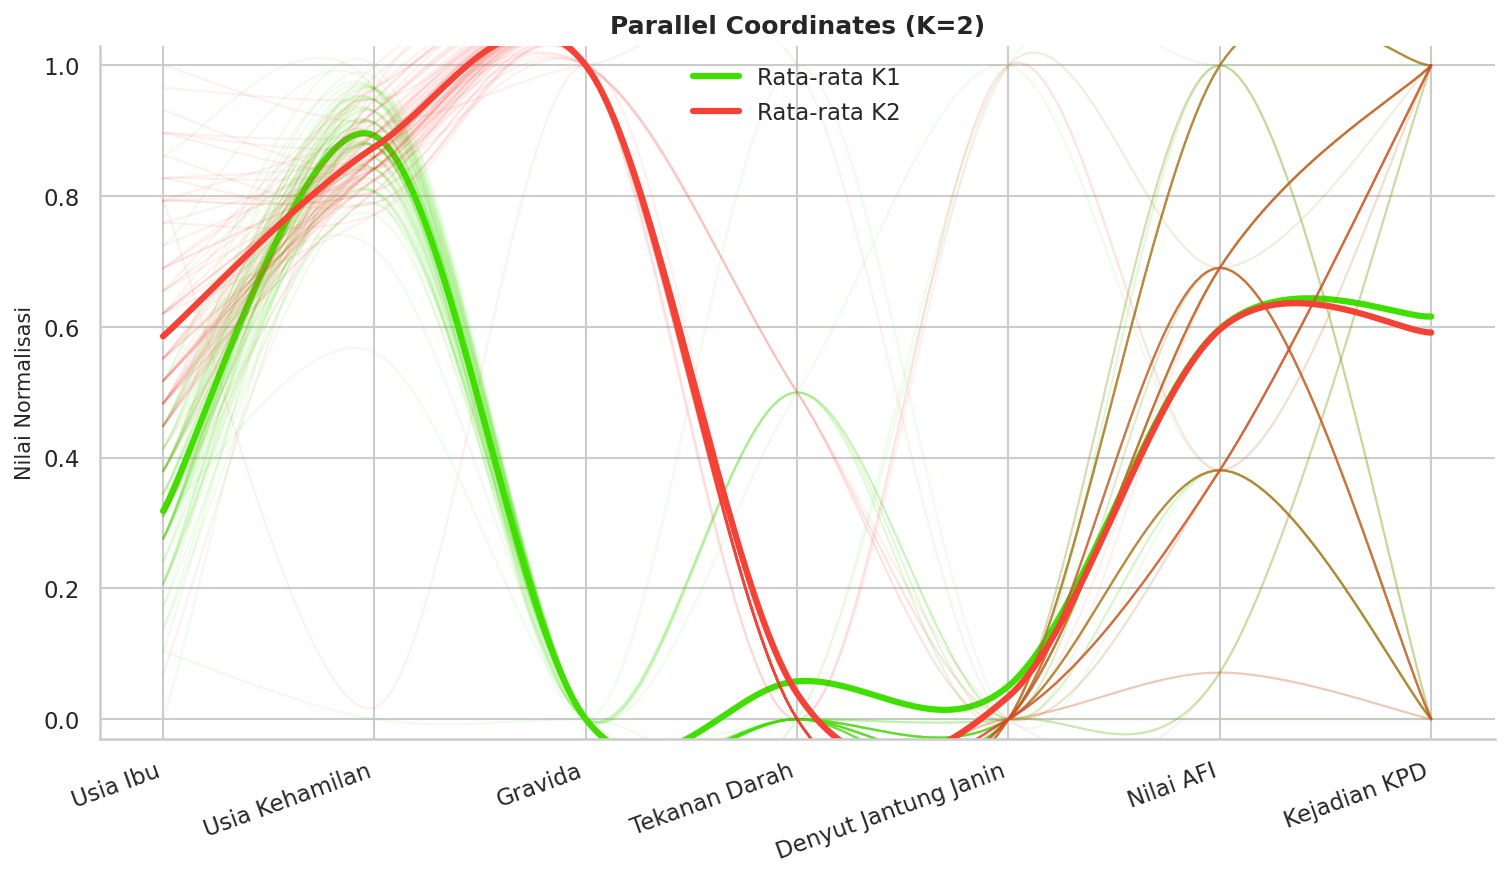

PC final        : 0.660145 (Baik)
Evaluasi dan visualisasi (K=2) berhasil diperbarui.


,No,Nomor RM,K1,K2,μ1²,μ2²,Hasil,Prediksi Tindakan,Tindakan Aktual,Tindakan Aktual Bersih,Prediksi Ringkas,Kesesuaian Tindakan
0,1,54121,0.206137,0.793863,0.042492,0.630219,K2,SC cito / SC,sc,sc,sc cito / sc,Selaras
1,2,65046,0.286040,0.713960,0.081819,0.509739,K2,SC cito / SC,sc,sc,sc cito / sc,Selaras
2,3,78533,0.200649,0.799351,0.040260,0.638963,K2,SC cito / SC,sc,sc,sc cito / sc,Selaras
3,4,83531,0.886686,0.113314,0.786213,0.012840,K1,Konservatif / Induksi / Partus spontan,sc,sc,konservatif / induksi / partus spontan,Perlu Review
4,5,79120,0.256447,0.743553,0.065765,0.552871,K2,SC cito / SC,sc,sc,sc cito / sc,Selaras


In [9]:
preprocessing_df = pd.read_csv(OUTPUT_DIR / "output_preprocessing.csv")
final_df = pd.read_csv(OUTPUT_DIR / "output_fcm_final.csv")
centers_df = pd.read_csv(OUTPUT_DIR / "output_pusat_klaster.csv")
pc_history = json.loads((ARTIFACT_DIR / "pc_history.json").read_text(encoding="utf-8"))
training_summary = json.loads((ARTIFACT_DIR / "training_summary.json").read_text(encoding="utf-8"))

cluster_indices = np.argmax(final_df[["K1", "K2"]].to_numpy(dtype=float), axis=1)
dominant_labels = [CLUSTER_LABELS[index] for index in cluster_indices]
cluster_colors = [CLUSTER_COLORS[label] for label in dominant_labels]
centers_numeric = centers_df[FEATURE_COLUMNS].to_numpy(dtype=float)

output_eval = final_df.copy()
output_eval["Tindakan Aktual Bersih"] = output_eval["Tindakan Aktual"].fillna("").apply(clean_action_text)
output_eval["Prediksi Ringkas"] = output_eval["Prediksi Tindakan"].apply(summarize_prediction)
output_eval["Kesesuaian Tindakan"] = [classify_alignment(label, action) for label, action in zip(output_eval["Hasil"], output_eval["Tindakan Aktual"].fillna(""))]
output_eval.to_csv(EVALUATION_DIR / "output_evaluasi_tindakan.csv", index=False, encoding="utf-8-sig")

pc_final = float(pc_history["pc_final"])
pc_label = interpret_pc(pc_final)
cluster_counts = pd.Series(dominant_labels).value_counts().reindex(CLUSTER_LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(10.5, 7))
ax.set_facecolor("#FCFCFC")
for cluster_label in CLUSTER_LABELS:
    mask = np.array(dominant_labels) == cluster_label
    ax.scatter(preprocessing_df.loc[mask, "Nilai AFI"], preprocessing_df.loc[mask, "Usia Ibu"], s=62, alpha=0.82, c=CLUSTER_COLORS[cluster_label], edgecolors="white", linewidths=0.8, label=f"{cluster_label} ({mask.sum()})", zorder=2)
for index, cluster_label in enumerate(CLUSTER_LABELS):
    center_x, center_y = centers_numeric[index, FEATURE_COLUMNS.index("Nilai AFI")], centers_numeric[index, FEATURE_COLUMNS.index("Usia Ibu")]
    ax.scatter(center_x, center_y, marker="*", s=420, color="#1F1F1F", edgecolors=CLUSTER_COLORS[cluster_label], linewidths=2.2, zorder=4)
    ax.annotate(f"C{index + 1}", (center_x, center_y), xytext=(8, 8), textcoords="offset points", fontsize=10, fontweight="bold", color="#1F1F1F", bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=CLUSTER_COLORS[cluster_label], lw=1), zorder=5)
count_summary = "\n".join([f"{label}: {cluster_counts[label]} pasien" for label in CLUSTER_LABELS])
ax.text(0.985, 0.03, count_summary, transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="#2D2D2D", bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#D9D9D9", lw=1, alpha=0.95))
ax.set_title("Scatter Plot Clustering FCM (K=2) – Oligohydramnion", pad=12)
ax.set_xlabel("Nilai AFI (Normalisasi)")
ax.set_ylabel("Usia Ibu (Normalisasi)")
ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
ax.grid(alpha=0.22, linestyle="--", linewidth=0.7)
ax.legend(title="Klaster Dominan", frameon=True, fancybox=True, facecolor="white", edgecolor="#D9D9D9", loc="upper left")
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_scatter_plot.png")

membership_plot_df = final_df.copy()
membership_plot_df["Dominan"] = dominant_labels
membership_plot_df["Membership Dominan"] = membership_plot_df[["K1", "K2"]].max(axis=1)
membership_plot_df["Ketidakpastian"] = 1 - membership_plot_df["Membership Dominan"]
membership_subset_frames = []
max_per_cluster = 12
for cluster_label in CLUSTER_LABELS:
    cluster_subset = membership_plot_df.loc[membership_plot_df["Dominan"] == cluster_label].copy()
    cluster_subset = cluster_subset.sort_values(["Ketidakpastian", "Nomor RM"], ascending=[False, True]).head(max_per_cluster)
    membership_subset_frames.append(cluster_subset)
membership_subset_df = pd.concat(membership_subset_frames, ignore_index=True).sort_values(["Dominan", "Ketidakpastian"], ascending=[True, False]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, max(7, len(membership_subset_df) * 0.38)))
y_positions, left = np.arange(len(membership_subset_df)), np.zeros(len(membership_subset_df))
for column, cluster_label in zip(["K1", "K2"], CLUSTER_LABELS):
    values = membership_subset_df[column].to_numpy(dtype=float)
    ax.barh(y_positions, values, left=left, color=CLUSTER_COLORS[cluster_label], label=cluster_label)
    left += values
ax.set_yticks(y_positions); ax.set_yticklabels(membership_subset_df["Nomor RM"].astype(str))
ax.invert_yaxis(); ax.set_xlim(0, 1)
ax.set_xlabel("Derajat Keanggotaan"); ax.set_ylabel("Nomor RM Terpilih")
ax.set_title("Membership Degree Pasien Terpilih (K=2)")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.2, linestyle="--")
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_membership_degree.png")

angles = np.linspace(0, 2 * np.pi, len(FEATURE_COLUMNS), endpoint=False).tolist(); angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
for index, cluster_label in enumerate(CLUSTER_LABELS):
    values = centers_numeric[index].tolist(); values += values[:1]
    ax.plot(angles, values, color=CLUSTER_COLORS[cluster_label], linewidth=2, label=cluster_label)
    ax.fill(angles, values, color=CLUSTER_COLORS[cluster_label], alpha=0.12)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(FEATURE_COLUMNS)
ax.set_title("Radar Chart Profil Risiko (K=2)")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1), frameon=False)
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_radar_chart.png")

cluster_means = [preprocessing_df.loc[np.array(dominant_labels) == label, FEATURE_COLUMNS].mean() for label in CLUSTER_LABELS]
heatmap_df = pd.DataFrame(cluster_means, index=CLUSTER_LABELS)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=False, cmap="RdYlGn_r", vmin=0, vmax=1, ax=ax)
for r in range(heatmap_df.shape[0]):
    for c in range(heatmap_df.shape[1]):
        v = float(heatmap_df.iloc[r, c])
        ax.text(c + 0.5, r + 0.5, f"{v:.3f}", ha="center", va="center", color="white" if v <= 0.20 or v >= 0.75 else "black", fontsize=11, fontweight="bold")
ax.set_title("Heatmap Rata-rata Fitur (K=2)")
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_heatmap.png")

fig, axes = plt.subplots(2, 4, figsize=(16, 8)); axes = axes.flatten()
plot_df = preprocessing_df.copy(); plot_df["Klaster"] = dominant_labels
for axis, feature_name in zip(axes, FEATURE_COLUMNS):
    sns.boxplot(data=plot_df, x="Klaster", y=feature_name, hue="Klaster", order=CLUSTER_LABELS, hue_order=CLUSTER_LABELS, palette=CLUSTER_COLORS, legend=False, ax=axis)
    axis.set_title(feature_name); axis.set_xlabel("")
axes[-1].axis("off")
fig.suptitle("Boxplot Distribusi Fitur per Klaster (K=2)", y=1.02)
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_boxplot.png")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))
iteration_axis = range(1, len(pc_history["pc_history"]) + 1)
axes[0].plot(iteration_axis, pc_history["pc_history"], marker="o", color="#2F6BFF", linewidth=2)
axes[0].axhline(pc_final, color="#F44336", linestyle="--", linewidth=1.2, alpha=0.85)
axes[0].set_title("Partition Coefficient (K=2)")
axes[0].set_xlabel("Iterasi"); axes[0].set_ylabel("PC"); axes[0].grid(alpha=0.25)
axes[0].text(
    0.98,
    0.04,
    f"PC Final: {pc_final:.3f}\nInterpretasi: {pc_label}",
    transform=axes[0].transAxes,
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#1F1F1F",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#D9D9D9", lw=1, alpha=0.95),
)
axes[1].pie(cluster_counts.values, labels=cluster_counts.index, colors=[CLUSTER_COLORS[label] for label in cluster_counts.index], autopct="%1.1f%%")
axes[1].set_title("Distribusi Klaster (K=2)")
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_validasi_pc.png")

fig, ax = plt.subplots(figsize=(12, 6))
feature_positions = np.arange(len(FEATURE_COLUMNS), dtype=float)
for cluster_label in CLUSTER_LABELS:
    mask = np.array(dominant_labels) == cluster_label
    cluster_data = preprocessing_df.loc[mask, FEATURE_COLUMNS].to_numpy(dtype=float)
    for row in cluster_data[:80]:
        sx, sy = catmull_rom_smooth(feature_positions, row, samples_per_segment=35)
        ax.plot(sx, sy, color=CLUSTER_COLORS[cluster_label], alpha=0.08, linewidth=1)
    if len(cluster_data):
        cluster_mean = cluster_data.mean(axis=0)
        sx, sy = catmull_rom_smooth(feature_positions, cluster_mean, samples_per_segment=45)
        ax.plot(sx, sy, color=CLUSTER_COLORS[cluster_label], linewidth=3, label=f"Rata-rata {cluster_label}")
ax.set_xticks(feature_positions); ax.set_xticklabels(FEATURE_COLUMNS, rotation=20, ha="right")
ax.set_ylim(-0.03, 1.03); ax.set_ylabel("Nilai Normalisasi"); ax.set_title("Parallel Coordinates (K=2)"); ax.legend(frameon=False)
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_parallel_coordinates_smooth.png")

prediksi_categories = output_eval["Prediksi Tindakan"].fillna("-")
actual_categories = output_eval["Tindakan Aktual Bersih"].replace("", "tanpa data")
source_labels = [f"Klaster: {label}" for label in output_eval["Hasil"]]
unique_nodes = list(dict.fromkeys(list(source_labels) + list(prediksi_categories) + list(actual_categories)))
node_index = {label: idx for idx, label in enumerate(unique_nodes)}
link_sources, link_targets, link_values = [], [], []
for _, row in output_eval.groupby(["Hasil", "Prediksi Tindakan"]).size().reset_index(name="value").iterrows():
    link_sources.append(node_index[f"Klaster: {row['Hasil']}"]); link_targets.append(node_index[row["Prediksi Tindakan"]]); link_values.append(int(row["value"]))
for _, row in output_eval.groupby(["Prediksi Tindakan", "Tindakan Aktual Bersih"]).size().reset_index(name="value").iterrows():
    label_actual = row["Tindakan Aktual Bersih"] if row["Tindakan Aktual Bersih"] else "tanpa data"
    link_sources.append(node_index[row["Prediksi Tindakan"]]); link_targets.append(node_index[label_actual]); link_values.append(int(row["value"]))
fig_sankey = go.Figure(data=[go.Sankey(node=dict(label=unique_nodes, pad=15, thickness=18), link=dict(source=link_sources, target=link_targets, value=link_values))])
fig_sankey.update_layout(title="Sankey Prediksi dan Tindakan (K=2)")
save_plotly_figure(fig_sankey, OUTPUT_DIR / "visualisasi_sankey_tindakan.html")

sunburst_df = output_eval.copy(); sunburst_df["Tindakan Aktual Bersih"] = sunburst_df["Tindakan Aktual Bersih"].replace("", "tanpa data")
fig_sunburst = px.sunburst(sunburst_df, path=["Hasil", "Prediksi Tindakan", "Kesesuaian Tindakan"], color="Hasil", color_discrete_map=CLUSTER_COLORS)
fig_sunburst.update_layout(title="Sunburst Ringkasan Tindakan (K=2)")
save_plotly_figure(fig_sunburst, OUTPUT_DIR / "visualisasi_sunburst_tindakan.html")

scatter3d_df = preprocessing_df.copy(); scatter3d_df["Klaster"] = dominant_labels
fig_3d = px.scatter_3d(scatter3d_df, x="Nilai AFI", y="Usia Ibu", z="Usia Kehamilan", color="Klaster", color_discrete_map=CLUSTER_COLORS, title="3D Scatter Plot (K=2)")
save_plotly_figure(fig_3d, OUTPUT_DIR / "visualisasi_3d_scatter.html")

print(f"PC final        : {pc_final:.6f} ({pc_label})")
print("Evaluasi dan visualisasi (K=2) berhasil diperbarui.")
output_eval.head()